In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fmendesdat263xdemos/exercise.csv
/kaggle/input/fmendesdat263xdemos/calories.csv


**Importing the Dependencies**

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn import set_config
import seaborn as sns
import matplotlib.pyplot as plt
set_config(display='diagram')

**Data Collection & Processing**

In [3]:
cal=pd.read_csv('/kaggle/input/fmendesdat263xdemos/calories.csv')
cal.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [4]:
exercise=pd.read_csv('/kaggle/input/fmendesdat263xdemos/exercise.csv')
exercise.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [5]:
calories = pd.concat([exercise, cal['Calories']], axis=1)
calories.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [6]:
calories.isna().sum()

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

**Data Visualization**

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='Calories', ylabel='Density'>

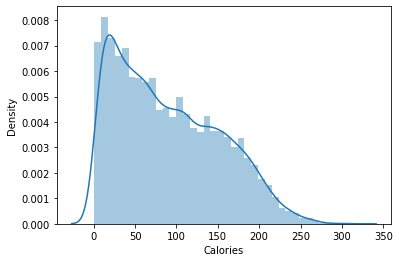

In [7]:
sns.distplot(calories.Calories)

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='Age', ylabel='Density'>

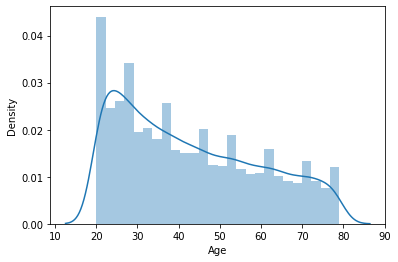

In [8]:
sns.distplot(calories.Age)

<AxesSubplot:>

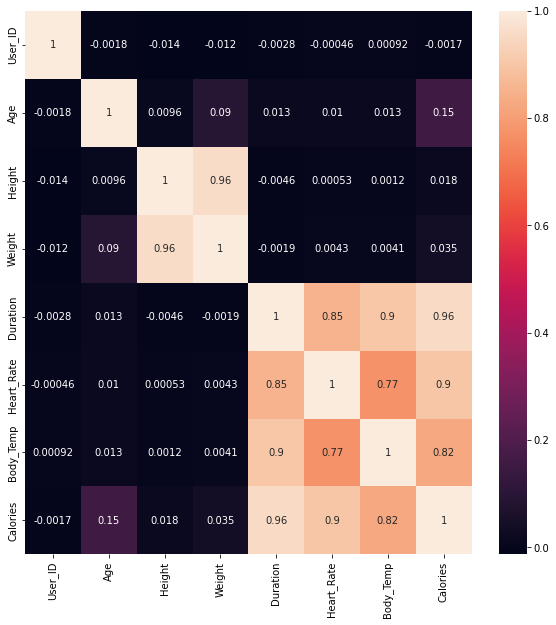

In [9]:
plt.figure(figsize=(10,10))
sns.heatmap(calories.corr(),annot=True)

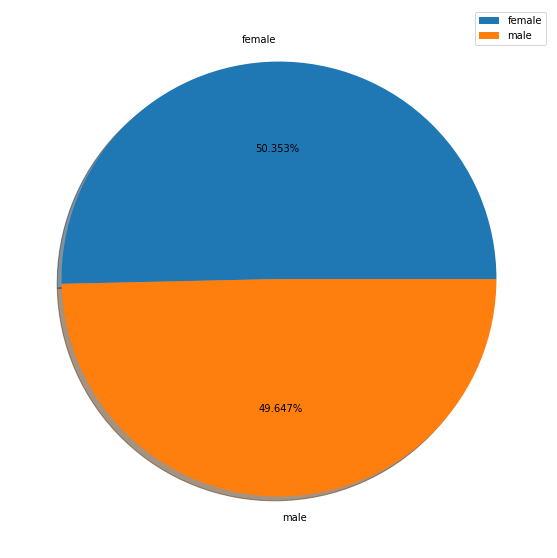

In [10]:
plt.figure(figsize=(10,10))
plt.pie(calories.Gender.value_counts(),labels=calories.Gender.value_counts().index,autopct="%.3f%%",shadow=True)
plt.legend()
plt.show()

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:xlabel='Duration', ylabel='Calories'>

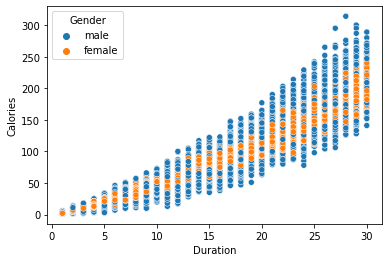

In [11]:
sns.scatterplot(calories.Duration,calories.Calories,hue=calories.Gender)

In [12]:
calories.Calories.mean()

89.53953333333334

In [13]:
calories.Calories.std()

62.45697795593845

In [14]:
calories.Calories.max()

314.0

In [15]:
calories.Calories.min()

1.0

In [16]:
calories.dtypes

User_ID         int64
Gender         object
Age             int64
Height        float64
Weight        float64
Duration      float64
Heart_Rate    float64
Body_Temp     float64
Calories      float64
dtype: object

In [17]:
calories.drop(columns=['User_ID'], axis=1,inplace=True)

In [18]:
calories.head()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,female,27,154.0,58.0,10.0,81.0,39.8,35.0


**Question**

1. Which Gender has to go through more exercise duration.
2. How many people with height more than 178.0 and weight less than 74.0 are females.
3. What is the average calories burned, when the exercise duration is more than 20.0.
4. How many people with heart rate less than 100.0 are males.
5. Is there any relationship between Duration and Calories.

In [19]:
# 1

calories.groupby('Gender').mean().iloc[:,-4]

Gender
female    15.502185
male      15.559420
Name: Duration, dtype: float64

In [20]:
# 2

calories[(calories.Height > 178.0) & (calories.Weight <  74.0) & (calories.Gender=="female")].count()[0]

107

In [21]:
# 3

calories[calories.Duration > 20.0].mean()[-1]

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:3: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  This is separate from the ipykernel package so we can avoid doing imports until


163.7155172413793

In [22]:
# 4

calories[(calories.Heart_Rate < 100.) & (calories.Gender == "male")].count()[0]

4729

In [23]:
# 5

calories.Duration.corr(calories.Calories)

0.9554205334742683

**Separating features and target**

In [24]:
nom_cols=[0]
scale_cols=[1]
y=calories[['Calories']]
x=calories.iloc[:,:-1]

In [25]:
s= StandardScaler()
y.Calories = s.fit_transform(y)

/opt/conda/lib/python3.7/site-packages/pandas/core/generic.py:5516: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[name] = value


In [26]:
transf=make_column_transformer((OneHotEncoder(sparse=False,drop='first'),nom_cols),
                              (StandardScaler(),scale_cols),
                             remainder='passthrough')
transf

ColumnTransformer(remainder='passthrough',
                  transformers=[('onehotencoder',
                                 OneHotEncoder(drop='first', sparse=False),
                                 [0]),
                                ('standardscaler', StandardScaler(), [1])])

**Splitting the data into Training data and Test data**

In [27]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)

In [28]:
print(x.shape,x_train.shape,x_test.shape)

(15000, 7) (10500, 7) (4500, 7)


**Model Training**

***Linear Regression***

In [29]:
model=LinearRegression()
model

LinearRegression()

In [30]:
pipe = make_pipeline(transf, model)
pipe

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(drop='first',
                                                                sparse=False),
                                                  [0]),
                                                 ('standardscaler',
                                                  StandardScaler(), [1])])),
                ('linearregression', LinearRegression())])

In [31]:
pipe.fit(x_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(drop='first',
                                                                sparse=False),
                                                  [0]),
                                                 ('standardscaler',
                                                  StandardScaler(), [1])])),
                ('linearregression', LinearRegression())])

**Evaluation**

In [32]:
ypred=pipe.predict(x_test)
ypred

array([[-1.20550943],
       [-0.36029958],
       [ 1.61661639],
       ...,
       [ 1.39105249],
       [ 0.33360769],
       [-0.57507054]])

**Mean Squared Error**

In [33]:
mean_squared_error(y_test,ypred)*100

3.4171587229708824

In [34]:
calories.head()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [35]:
pred = pipe.predict([['male',68,190.0,94.0,29.0,105.0,40.8]])

pred

/opt/conda/lib/python3.7/site-packages/sklearn/base.py:451: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  "X does not have valid feature names, but"
/opt/conda/lib/python3.7/site-packages/sklearn/base.py:451: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  "X does not have valid feature names, but"


array([[1.76008822]])

In [36]:
s.inverse_transform(pred)

array([[199.46565986]])

In [37]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

calories.Calories=scaler.fit_transform(calories[['Calories']])

In [38]:
round(calories.Calories.mean())

0

In [39]:
calories.Calories.std()

1.0000333350000925

In [40]:
calories.Calories.max()

3.593961097744743

In [41]:
calories.Calories.min()

-1.4176556038486092

In [42]:
calories.Calories

0        2.265002
1       -0.376905
2       -1.017367
3       -0.296847
4       -0.873263
           ...   
14995   -0.713147
14996   -1.065401
14997   -0.232801
14998   -1.257540
14999    0.135465
Name: Calories, Length: 15000, dtype: float64

In [43]:
from sklearn.preprocessing import MinMaxScaler

minmax=MinMaxScaler()

calories.Calories=minmax.fit_transform(calories[['Calories']])

calories.Calories

0        0.734824
1        0.207668
2        0.079872
3        0.223642
4        0.108626
           ...   
14995    0.140575
14996    0.070288
14997    0.236422
14998    0.031949
14999    0.309904
Name: Calories, Length: 15000, dtype: float64

In [44]:
calories.Calories.max()

1.0

In [45]:
calories.Calories.min()

0.0

In [46]:
calories.Calories.mean()

0.28287390841320553

In [47]:
calories.Calories.std()

0.19954306056210366

**Decision Tree Regressor**

In [48]:
from sklearn.tree import DecisionTreeRegressor
model2=DecisionTreeRegressor()
model2

DecisionTreeRegressor()

In [49]:
pipe2=make_pipeline(transf,model2)
pipe2.fit(x_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(drop='first',
                                                                sparse=False),
                                                  [0]),
                                                 ('standardscaler',
                                                  StandardScaler(), [1])])),
                ('decisiontreeregressor', DecisionTreeRegressor())])

**Evaluation**

In [50]:
ypred=pipe.predict(x_test)
ypred

array([[-1.20550943],
       [-0.36029958],
       [ 1.61661639],
       ...,
       [ 1.39105249],
       [ 0.33360769],
       [-0.57507054]])

**Mean Squared Error**

In [51]:
mean_squared_error(ypred,y_test)*100

3.4171587229708824

**Random Forest Regressor**

In [52]:
from sklearn.ensemble import RandomForestRegressor
model3=RandomForestRegressor()
model3

RandomForestRegressor()

In [53]:
pipe3=make_pipeline(transf,model3)
pipe3.fit(x_train,y_train)

/opt/conda/lib/python3.7/site-packages/sklearn/pipeline.py:394: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self._final_estimator.fit(Xt, y, **fit_params_last_step)


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(drop='first',
                                                                sparse=False),
                                                  [0]),
                                                 ('standardscaler',
                                                  StandardScaler(), [1])])),
                ('randomforestregressor', RandomForestRegressor())])

**Evaluation**

In [54]:
ypred=pipe3.predict(x_test)
ypred


array([-1.12032103, -0.4054051 ,  2.24546794, ...,  1.36899542,
        0.33625013, -0.62348248])

**Mean Squared Error**

In [55]:
mean_squared_error(ypred,y_test)*100

0.2003793902152406